# Que características aumentam a chance de atraso em um voo?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

In [ ]:
#Caminho do dado

flights_path = "../data/raw/flights.csv"
airports_path = "../data/raw/airports.csv"

df_flights = pd.read_csv(flights_path)
df_airports = pd.read_csv(airports_path)

print("Flights shape:", df_flights.shape)
print("Airports shape:", df_airports.shape)

df_flights.head()

C:\Users\BlueShift\AppData\Local\Temp\ipykernel_11960\1091790304.py:6: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv(flights_path)


Flights shape: (5819079, 31)
Airports shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Selecionar colunas 
cols = [
    "DEPARTURE_DELAY",
    "ARRIVAL_DELAY",
    "CANCELLED",
    "SCHEDULED_DEPARTURE",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT"
]

df = df_flights[cols].copy()

In [ ]:
#Limpeza de dados 

# remover cancelados
df = df[df["CANCELLED"] == 0]

# remover nulos
df = df.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

# criar flag de atraso
df["IS_DELAYED"] = df["ARRIVAL_DELAY"] > 15




In [ ]:
#Amostra

df_flights = pd.read_csv(flights_path, low_memory=False)


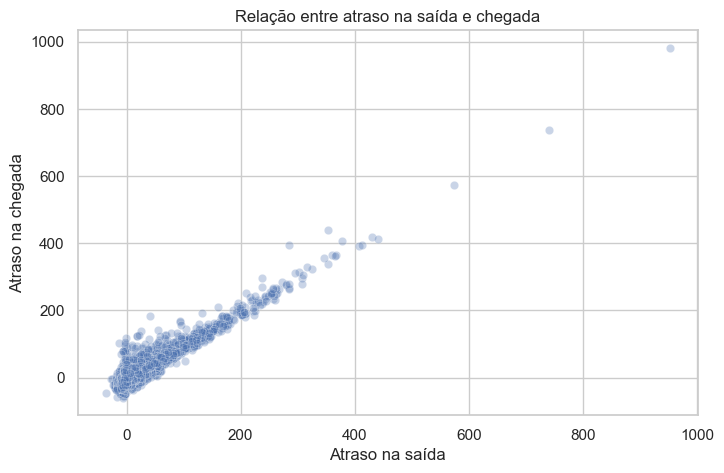

In [ ]:
#Relação atraso saída vs chegada

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(10000),
    x="DEPARTURE_DELAY",
    y="ARRIVAL_DELAY",
    alpha=0.3
)

plt.title("Relação entre atraso na saída e chegada")
plt.xlabel("Atraso na saída")
plt.ylabel("Atraso na chegada")

plt.show()

C:\Users\BlueShift\AppData\Local\Temp\ipykernel_11960\1892475486.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("PERIOD")["IS_DELAYED"]


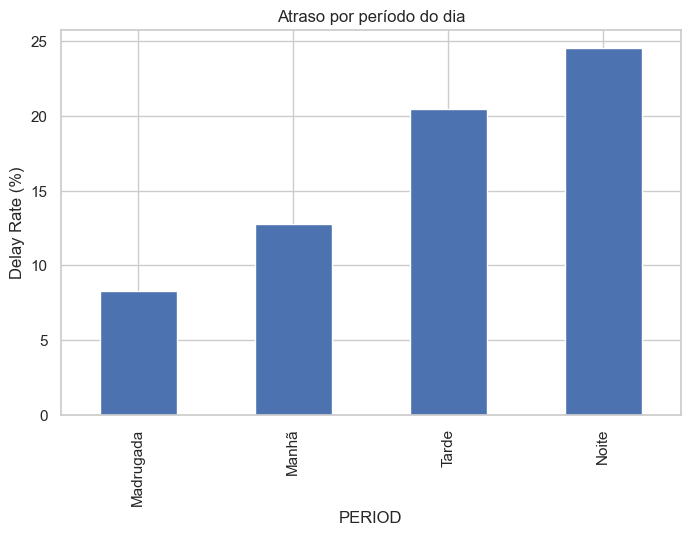

In [ ]:
#Atraso por período do dia

df["PERIOD"] = pd.cut(
    df["SCHEDULED_DEPARTURE"],
    bins=[0, 600, 1200, 1800, 2400],
    labels=["Madrugada", "Manhã", "Tarde", "Noite"]
)

delay_by_period = (
    df.groupby("PERIOD")["IS_DELAYED"]
    .mean() * 100
)

delay_by_period.plot(kind="bar", figsize=(8,5))

plt.title("Atraso por período do dia")
plt.ylabel("Delay Rate (%)")

plt.show()

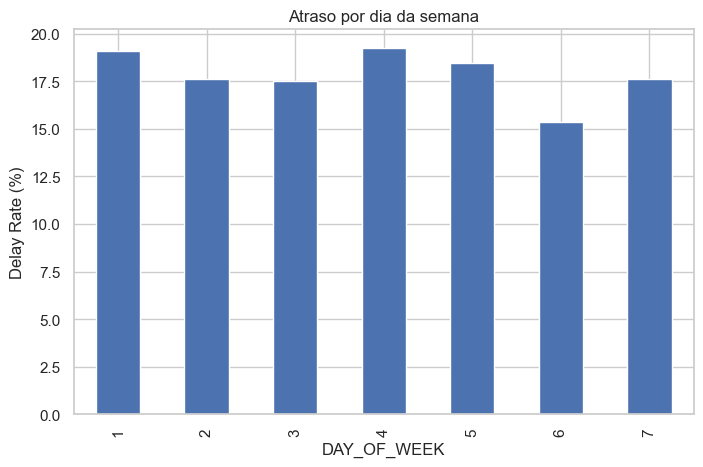

In [ ]:
#Atraso por dia

delay_by_day = (
    df.groupby("DAY_OF_WEEK")["IS_DELAYED"]
    .mean() * 100
)

delay_by_day.plot(kind="bar", figsize=(8,5))

plt.title("Atraso por dia da semana")
plt.ylabel("Delay Rate (%)")

plt.show()

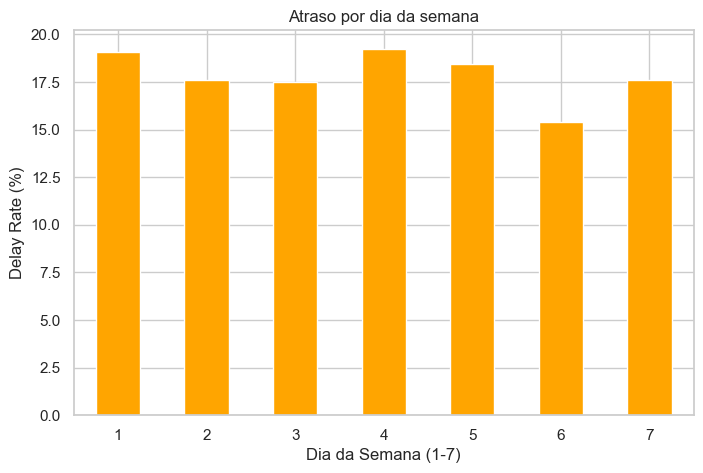

In [ ]:

delay_by_day = (
    df.groupby("DAY_OF_WEEK")["IS_DELAYED"]
    .mean() * 100
)

plt.figure(figsize=(8,5))
delay_by_day.plot(kind="bar", color="orange")

plt.title("Atraso por dia da semana")
plt.xlabel("Dia da Semana (1-7)")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)

plt.show()


In [ ]:
##Atraso por aeroporto 

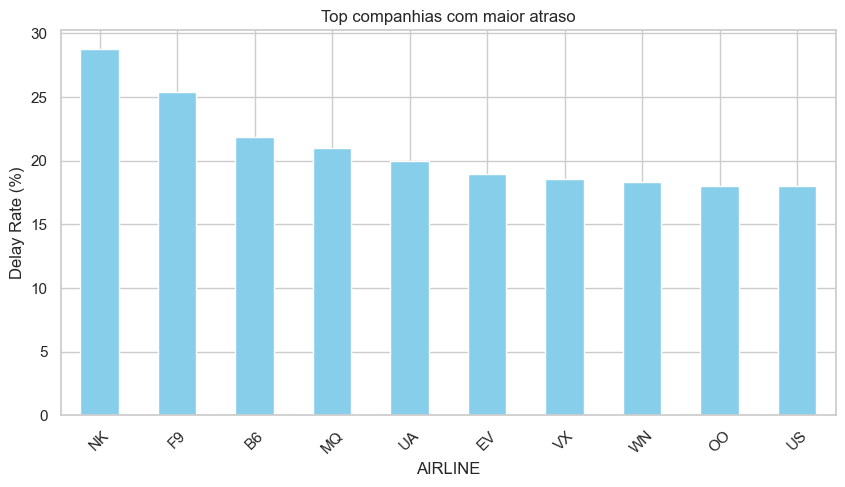

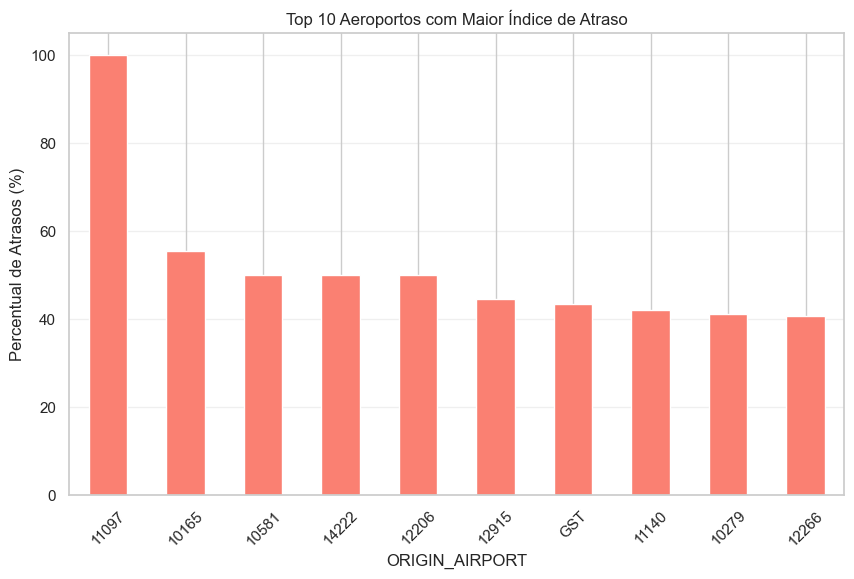

In [ ]:
delay_by_airline = (
    df.groupby("AIRLINE")["IS_DELAYED"]
    .mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
delay_by_airline.head(10).plot(kind="bar", color="skyblue")
plt.title("Top companhias com maior atraso")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.show()

# Atraso por aeroporto
delay_by_airport = (
    df.groupby("ORIGIN_AIRPORT")["IS_DELAYED"]
    .mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
delay_by_airport.head(10).plot(kind='bar', color='salmon')
plt.title("Top 10 Aeroportos com Maior Índice de Atraso")
plt.ylabel("Percentual de Atrasos (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Os atrasos são mais comuns em certos dias da semana ou horários?

C:\Users\BlueShift\AppData\Local\Temp\ipykernel_11960\1160766385.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_period = df.groupby("PERIOD")["IS_DELAYED"].mean() * 100
C:\Users\BlueShift\AppData\Local\Temp\ipykernel_11960\1160766385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_period.index, y=df_period.values, palette="viridis")


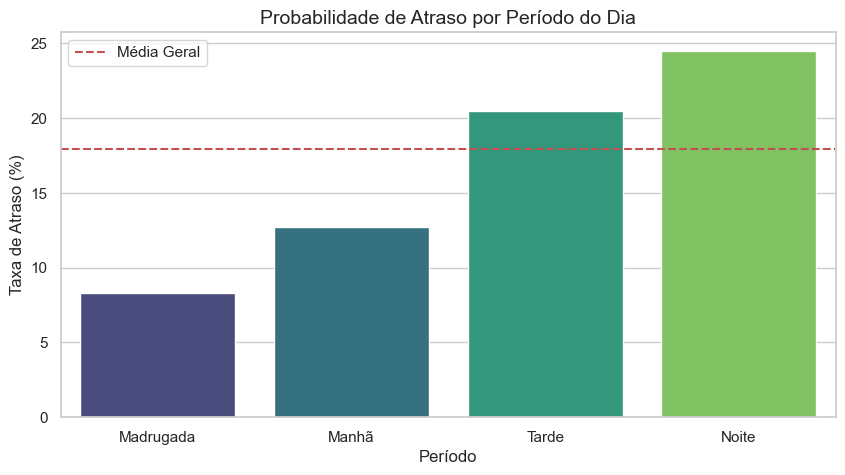

In [ ]:
#ANÁLISE POR PERÍODO DO DIA (Prova o efeito cascata ao longo do dia)
plt.figure(figsize=(10, 5))
df_period = df.groupby("PERIOD")["IS_DELAYED"].mean() * 100

# Criando o gráfico com Seaborn para um visual mais profissional
sns.barplot(x=df_period.index, y=df_period.values, palette="viridis")

plt.title("Probabilidade de Atraso por Período do Dia", fontsize=14)
plt.ylabel("Taxa de Atraso (%)")
plt.xlabel("Período")
plt.axhline(df["IS_DELAYED"].mean()*100, color='r', linestyle='--', label='Média Geral')
plt.legend()
plt.show()

C:\Users\BlueShift\AppData\Local\Temp\ipykernel_11960\327989075.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_airline.index, y=delay_airline.values, palette="magma")


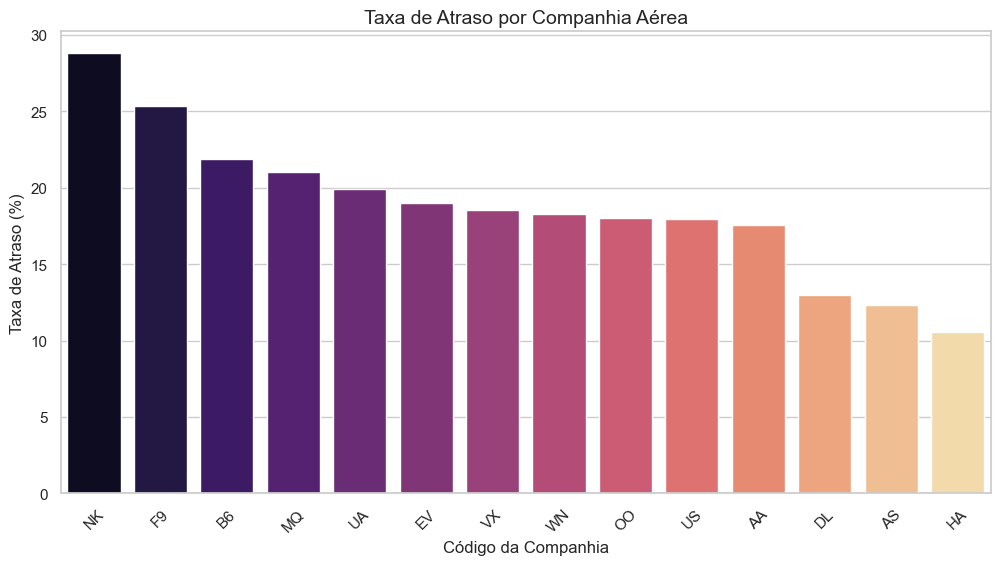

In [ ]:
#ANÁSILE POR COMPANHIA 
delay_airline = (df.groupby("AIRLINE")["IS_DELAYED"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=delay_airline.index, y=delay_airline.values, palette="magma")

plt.title("Taxa de Atraso por Companhia Aérea", fontsize=14)
plt.ylabel("Taxa de Atraso (%)")
plt.xlabel("Código da Companhia")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# =====================================================
# CONCLUSÕES FINAIS DA ANÁLISE EXPLORATÓRIA
# =====================================================

print(f"""
RESUMO DOS INSIGHTS (EDA):

1. CARACTERÍSTICAS QUE AUMENTAM O ATRASO:
   * ATRASO NA SAÍDA: É o principal preditor. O gráfico de dispersão confirma que a recuperação de 
     tempo em voo é rara; um atraso na saída quase sempre se traduz em atraso na chegada.
   * COMPANHIA E ORIGEM: A variação superior a 20% entre diferentes companhias e aeroportos 
     indica que fatores operacionais de solo (logística de pátio e eficiência da tripulação) 
     são determinantes críticos.

2. PADRÕES TEMPORAIS (DIAS E HORÁRIOS):
   * EFEITO CASCATA POR HORÁRIO: Os atrasos são progressivos. Voos no período da 'Tarde' e 'Noite' 
     têm chances significativamente maiores de atraso do que voos matinais, confirmando o 
     acúmulo de problemas na malha aérea ao longo do dia.
   * SAZONALIDADE SEMANAL: Os dias de maior fluxo (finais de semana e segundas) apresentam 
     picos de atraso, sugerindo que a saturação da infraestrutura aeroportuária 
     impacta diretamente na pontualidade.

PRÓXIMOS PASSOS PARA MODELAGEM:
* As variáveis 'DEPARTURE_DELAY', 'PERIOD', 'AIRLINE' e 'ORIGIN_AIRPORT' demonstraram alto 
  poder preditivo e devem ser priorizadas como features no treinamento do modelo.
""")


RESUMO DOS INSIGHTS (EDA):

1. CARACTERÍSTICAS QUE AUMENTAM O ATRASO:
   * ATRASO NA SAÍDA: É o principal preditor. O gráfico de dispersão confirma que a recuperação de 
     tempo em voo é rara; um atraso na saída quase sempre se traduz em atraso na chegada.
   * COMPANHIA E ORIGEM: A variação superior a 20% entre diferentes companhias e aeroportos 
     indica que fatores operacionais de solo (logística de pátio e eficiência da tripulação) 
     são determinantes críticos.

2. PADRÕES TEMPORAIS (DIAS E HORÁRIOS):
   * EFEITO CASCATA POR HORÁRIO: Os atrasos são progressivos. Voos no período da 'Tarde' e 'Noite' 
     têm chances significativamente maiores de atraso do que voos matinais, confirmando o 
     acúmulo de problemas na malha aérea ao longo do dia.
   * SAZONALIDADE SEMANAL: Os dias de maior fluxo (finais de semana e segundas) apresentam 
     picos de atraso, sugerindo que a saturação da infraestrutura aeroportuária 
     impacta diretamente na pontualidade.

PRÓXIMOS PASS